In [1]:
############################## U & V Wind Forcing File #####################################
# The purpose of this script is to make a forcing file for u and v wind using ERA5 data
# from 2017 - 2024 to use for bulk fluxes for ROMS. 
#
# Notes:
# - We will like hold off on interpolating and let ROMS interpolate the data instead...
#   but if this gets wonky then this script will interpolate it before saving it.
# - ERA5 data is hourly starting at hour 1 day 1 each year; time in ERA5? output is 
#   UTC so subtract 9 for standard time and 8 for daylight savings...but I think do something uniform 
#   for now so subtract 8 for now...
#
############################################################################################

In [2]:
# Load in packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
from matplotlib import colors
import cartopy.crs as ccrs
from cartopy import config
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean 
import xarray as xr
import datetime
from datetime import datetime, timedelta
import xesmf as xe
#import ESMF
from netCDF4 import Dataset
from datetime import datetime, timedelta
from cftime import num2date, date2num
import pandas as pd  
import math
#from PythonMETAR import *

In [3]:
# Load in the grid
grid = xr.open_dataset('/global/homes/b/bundzis/Projects/Beaufort_ROMS_2020_test_nosed/Include/KakAKgrd_shelf_big010_smooth006_thin_sponge.nc')


In [4]:
# Set a bunch of dimensions 

# Pull out the angle to rotate the currents to match the grid's u,v
phi = grid.angle[0,0].values # radians 

# Read in the dimensions
# rho
eta_rho_len = len(grid.eta_rho) # 206
xi_rho_len = len(grid.xi_rho) # 608
# u
eta_u_len = len(grid.eta_u) # 206
xi_u_len = len(grid.xi_u) # 607
# v
eta_v_len = len(grid.eta_v) #
xi_v_len = len(grid.xi_v) # 

# Define other dimension lengths
# eta rho
Mp = len(grid.eta_rho)
# xi rho
Lp = len(grid.xi_rho)

# latitude
lat_u_len = len(grid.lat_u)
lat_v_len = len(grid.lat_v)

# longitude
lon_u_len = len(grid.lon_u)
lon_v_len = len(grid.lon_v)


In [5]:
# Load in the ERA5 wind data 
era5_winds = xr.open_dataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_2020_dvd_myroms_ice_scratch/External_data/ERA5_data/uwind_vwind_10m_era5_2017_2024.nc')

In [6]:
# Pull out dimensions 
era5_lon_len = len(era5_winds.longitude)
print('era5_lon_len: ', era5_lon_len)
era5_lat_len = len(era5_winds.latitude)
print('era5_lat_len: ', era5_lat_len)

era5_time_len = len(era5_winds.valid_time)
print('era5_time_len: ', era5_time_len)
print(era5_winds.valid_time)

era5_lon_len:  77
era5_lat_len:  21
era5_time_len:  70128
<xarray.DataArray 'valid_time' (valid_time: 70128)> Size: 561kB
array(['2017-01-01T00:00:00.000000000', '2017-01-01T01:00:00.000000000',
       '2017-01-01T02:00:00.000000000', ..., '2024-12-31T21:00:00.000000000',
       '2024-12-31T22:00:00.000000000', '2024-12-31T23:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 561kB 2017-01-01 ... 2024-12-31T2...
Attributes:
    standard_name:  time
    long_name:      time
    axis:           T


In [7]:
# Make a time array of the times we want 
# ERA5 data spans 2017-01-01 hour 1 to 2024-12-31 hour 23 (hourly)
# Make a datetime array of the corresponding datetime values in AKDT to use for the netcdf
time_utc = np.arange(datetime(2017,7,1,hour=1,minute=0,second=0), datetime(2024,12,31,hour=23,minute=0, second=0),timedelta(hours=1)) # in UTC, ERA5 time
time_akdt = np.arange(datetime(2016,12,31,hour=16,minute=0,second=0), datetime(2024,12,31,hour=16,minute=0, second=0),timedelta(hours=1)) # in AKT (daylight savings...March - November...)

time_akdt_dt = pd.to_datetime(time_akdt)
print(time_akdt_dt[0:7])
print(time_akdt_dt[-9:-1])
print(time_akdt_dt[-1])
print(len(time_akdt_dt))

DatetimeIndex(['2016-12-31 16:00:00', '2016-12-31 17:00:00',
               '2016-12-31 18:00:00', '2016-12-31 19:00:00',
               '2016-12-31 20:00:00', '2016-12-31 21:00:00',
               '2016-12-31 22:00:00'],
              dtype='datetime64[us]', freq=None)
DatetimeIndex(['2024-12-31 07:00:00', '2024-12-31 08:00:00',
               '2024-12-31 09:00:00', '2024-12-31 10:00:00',
               '2024-12-31 11:00:00', '2024-12-31 12:00:00',
               '2024-12-31 13:00:00', '2024-12-31 14:00:00'],
              dtype='datetime64[us]', freq=None)
2024-12-31 15:00:00
70128


In [8]:
# Check for leap day(s)
print(time_akdt_dt[27708])
print(((30*24)+(28*24)))

2020-02-29 04:00:00
1392


In [9]:
# # Get the times we want? like slice to match to local time for the times we want?
# # Or just know that ERA5 is UTC so when making the time variable to use for the forcing files, 
# # make sure to convert to Alaska time

# # Not sure if I actually need this code...Since I am just going to do all times

# # extract July - October for analysis (use this for both u10 and v10)
# # *** CHANGE THIS TO PULL THIS TIME PERIOD IN LOCAL TIME *** --> make sure to convert this correctly with new ERA5 data which should be fine...
# #era5_openwater_data = era5_data_cp.sel(time=slice('2019-07-01', '2019-11-01'))
# #era5_openwater_data = era5_data_cp.sel(time=slice('2019-07-01 08:00:00', '2019-11-01 21:00:00')) # to get 2019-07-01 00:00:00 - 2019-11-01 12:00:00 AKDT; version 002
# era5_openwater_data = era5_data_cp.sel(valid_time=slice('2020-07-01 09:00:00', '2020-11-02 09:00:00')) # to get 2019-07-01 01:00:00 - 2019-11-02 01:00:00 AKDT; version 003
# print(era5_openwater_data.valid_time[0].values)
# print(era5_openwater_data.valid_time[-1].values)
# print('len era5: ', len(era5_openwater_data.valid_time))

# # Make an array of the datetimes in local Kaktovik, AK time to use
# # for the netcdf file 
# time_akdt = np.arange(pd.datetime(2020,7,1,hour=1,minute=0,second=0), pd.datetime(2020,11,2,hour=2,minute=0, second=0),timedelta(hours=1))
# print('AKDT: ', time_akdt[0:9])
# print('AKDT: ', time_akdt[-9:-1])
# print('AKDT: ', time_akdt[-1])
# print('len AKDT: ', len(time_akdt))

In [10]:
# make python do time to seconds 
# convert all the times to seconds since 2000-01-01 (really 1999-12-31 so it start at beginning of year=hour 0)
time_tmp = ((time_akdt_dt[:] - datetime(1999,12,31)).total_seconds() - 86400)

In [11]:
# Flip over latitude
# KEEPING THIS BECAUSE IT WORKED; WE NEED TO FLIP LATITUDE TO BE INCREASING
# Looks like we might need latitude to be increasing so we need to flip some things 
# Let's first just try flipping the values for the variable but then do we also need to 
# flip the variables that depend on them? --> YES
lat_flip = np.flip(era5_winds.latitude.values)

### Set up the NetCDF

In [12]:
# Set up the netcdf for the forcing file 
# ------------------------------- Create the u netCDF file ---------------------------

#name of file I am writing to
wind_frc = '/pscratch/sd/b/bundzis/Beaufort_ROMS_2020_dvd_myroms_ice_scratch/Forcing_files/wind_forcing_file_kaktovik_shelf_era5_data_2017_2024_flip_001.nc'   #UPDATE PATH

#create file to write to
nc1 = Dataset(wind_frc, 'w', format='NETCDF4')

#Global attributes
global_defaults = dict(gridname = 'KakAKgrd_shelf_big010_smooth006_thin_sponge.nc',
                      type = 'ROMS grid interpolated ERA5 uwind forcing',
                      history = 'Created by Brianna Undzis',
                      Conventions = 'CF',
                      Institution = 'University of Colorado Boulder',
                      date = str(datetime.today()))
    
#create dictionary for model
d = {}
d = global_defaults

for att, value in d.items():
    setattr(nc1, att, value)

# Create dimensions
# nc1.createDimension('xi_rho',  xi_rho_len)   # rho
# nc1.createDimension('eta_rho', eta_rho_len)
nc1.createDimension('lon',  era5_lon_len)   # rho
nc1.createDimension('lat', era5_lat_len)
nc1.createDimension('wind_time', None)
nc1.createDimension('one',     1)

# Create variables 
# --------------------
# Coordinate Variables
# --------------------
# era5 lon
lon = nc1.createVariable('lon', 'd', ('lon',), zlib=True)
lon.long_name = 'longitude coordinate of ERA5 data'
lon.standard_name = 'projection_lon_coordinate'
lon.units = 'degrees'
lon_tmp = era5_winds.longitude
lon[:] = lon_tmp[:]

# era5 lat
lat = nc1.createVariable('lat', 'd', ('lat',), zlib=True)
lat.long_name = 'latitude coordinate of ERA5 data'
lat.standard_name = 'projection_lat_coordinate'
lat.units = 'degrees'
#lat_tmp = era5_winds.latitude
lat_tmp = lat_flip # FLIP
lat[:] = lat_tmp[:]

# shf_time (in seconds)
wind_time_g = nc1.createVariable('wind_time', None, ('wind_time'), zlib=True)
wind_time_g.long_name = 'seconds since 2000-01-01 00:00:00' #with initialization of 2000-01-01 00:00:00
wind_time_g.units = 'second'
wind_time_g.field = 'time, scalar, series'
wind_time_g[:] = time_tmp[:]

# --------------------
# Winds
# --------------------

# uwind
uwind_interp_g = nc1.createVariable('Uwind', 'f8', ('wind_time', 'lat', 'lon'), zlib=True)
uwind_interp_g.long_name = 'u-wind component 10-m above surface'
uwind_interp_g.standard_name = 'surface_x_wind'
uwind_interp_g.units = 'meter second-1' 
uwind_interp_g.coordinates = 'lon lat' # or try lat lon

# vwind
vwind_interp_g = nc1.createVariable('Vwind', 'f8', ('wind_time', 'lat', 'lon'), zlib=True)
vwind_interp_g.long_name = 'v-wind component 10-m above surface'
vwind_interp_g.standard_name = 'surface_y_wind'
vwind_interp_g.units = 'meter second-1' 
vwind_interp_g.coordinates = 'lon lat' # or try lat lon

# ------------------------------- End u netCDF setup ---------------------------

In [13]:
# Putting this here just in case
# # Set the input and output grids, and sepcify the lat/lon
# # Since we are looking at sustr for now, we will use lon_u and lat_u as the primary lat/lon for the grid 
# # Input grid (HYCOM)
# ds_in_hycom = qtot_all.copy() # need to use lon_180 for this grid 
# ds_in_hycom['lon_360'] = ds_in_hycom.lon.values
# ds_in_hycom['lon'] = ds_in_hycom.lon_180.values

# # Output grid (ROMS u grid)
# ds_out_rho = grid.copy()
# ds_out_rho['lat'] = (('eta_rho', 'xi_rho'), ds_out_rho.lat_rho.values)
# ds_out_rho['lon'] = (('eta_rho', 'xi_rho'), ds_out_rho.lon_rho.values)

# # Add masks 
# # ex: ds["mask"] = xr.where(~np.isnan(ds["zeta"].isel(ocean_time=0)), 1, 0)
# # Input grid (HYCOM)
# # this is only a surface mask - which is what we want 
# ds_in_hycom_mask = xr.where(~np.isnan(ds_in_hycom['qtot'][0,:,:].values), 1, 0) 
# ds_in_hycom['mask'] = (('lat', 'lon'), ds_in_hycom_mask)

# # Output grid (ROMS u grid)
# ds_out_rho['mask'] = (('eta_rho', 'xi_rho'), ds_out_rho.mask_rho.values)

# # Regrid from HYCOM grid to u grid with the masks included and extrapolation used 
# regridder_hycom2rho = xe.Regridder(ds_in_hycom, ds_out_rho, method="bilinear", extrap_method='inverse_dist') #extrap_method="nearest_s2d"
# regridder_hycom2rho

# # Save the weights - only need to do this once
# fn_hycom2rho = regridder_hycom2rho.to_netcdf('regrid_hycom2rho_weights.nc')
# #print(fn_hycom2u)

# # Now use the regridder/weights to regrid zeta  
# dr_hycom2rho_qtot = qtot_all['qtot'].copy()
# dr_out_hycom2rho_qtot = regridder_hycom2rho(dr_hycom2rho_qtot) 
# dr_out_hycom2rho_qtot

# # Use fill.f90 to fill the nans in the array
# # Import fill.f90 from model2roms to see how to 
# # use this/if it can be used to get rid of nans 
# from numpy import f2py
# with open('/Users/brun1463/Desktop/Research_Lab/Kaktovik_Alaska_2019/ROMS_interpolate_data_scripts_output/scripts_2/fill.f90') as sourcefile2:
#     sourcecode2 = sourcefile2.read()
# f2py.compile(sourcecode2, modulename='fill', extension='.f90')
# import fill

# # Define a function to call to do the filling, taken from model2roms
# def laplacefilter(field, threshold, toxi, toeta):
#     undef = 2.0e+35 
#     tx = 0.9 * undef
#     critx = 0.01
#     cor = 1.6
#     mxs = 10

#     field = np.where(abs(field) > threshold, undef, field)

#     field = fill.extrapolate.fill(int(1), int(toxi),
#                                 int(1), int(toeta),
#                                 float(tx), float(critx), float(cor), float(mxs),
#                                 np.asarray(field, order='F'),
#                                 int(toxi),
#                                 int(toeta))
#     return field

# # Loop through time to fill in the nans
# # Make some variables first
# toxi = xi_rho_len
# toeta = eta_rho_len

# # Make an array to hold the new data without nans
# #print('got here 1')
# dr_out_hycom2rho_qtot_nonan = np.empty((time_len, eta_rho_len, xi_rho_len))
# #print('got here 2')

# # Make a copy of the OG array to work with
# #print('got here 3')
# dr_out_hycom2rho_qtot_cp1 = dr_out_hycom2rho_qtot.copy() 
# #print('got here 4')

# # Loop through depth to replace all the nans with real values 
# # Loop through time
# for t in range(time_len):
#     # Print the time 
#     print('t: ', t)

#     # Pull out the horizontal 'field' for that time
#     field = dr_out_hycom2rho_qtot_cp1[t,:,:]

#     # Use the Laplace Filter to get rid of nans
#     field = laplacefilter(field, 1000, toxi, toeta)

#     # Multiply by the u mask 
#     field = field * ds_out_rho.mask.values

#     # Check to see if there are any nans
#     #print('nans: ', np.where(np.isnan(field)))
#     #print('nanmin: ', np.nanmin(field))
#     #print('nanmax: ', np.nanmax(field))
#     #input('press enter to continue...')

#     # Save this field to a new array
#     dr_out_hycom2rho_qtot_nonan[t,:,:] = field

In [14]:
# Flip so that latitude is increasing 
uwinds_flip = np.flip(era5_winds.u10[:,:,:], axis=1)
vwinds_flip = np.flip(era5_winds.v10[:,:,:], axis=1)

In [15]:
# Since we are not interpolating, just save the data to the netcdf?
# Save the interpolated/regridded zeta to the netcdf files
# to the climatology file
uwind_interp_g[:,:,:] = uwinds_flip[:,:,:]
vwind_interp_g[:,:,:] = vwinds_flip[:,:,:]

In [16]:
# Close the netcdf?
# Close the netcdfs
nc1.close()

### Check the File
Open the forcing file just made and check it

In [17]:
# Load in the file
wind_frc_file = xr.open_dataset('/pscratch/sd/b/bundzis/Beaufort_ROMS_2020_dvd_myroms_ice_scratch/Forcing_files/wind_forcing_file_kaktovik_shelf_era5_data_2017_2024_flip_001.nc')

In [18]:
wind_frc_file

<xarray.Dataset> Size: 2GB
Dimensions:    (lon: 77, lat: 21, wind_time: 70128)
Coordinates:
  * lon        (lon) float64 616B -156.0 -155.8 -155.5 ... -137.5 -137.2 -137.0
  * lat        (lat) float64 168B 68.0 68.25 68.5 68.75 ... 72.5 72.75 73.0
  * wind_time  (wind_time) float64 561kB 5.365e+08 5.365e+08 ... 7.89e+08
Data variables:
    Uwind      (wind_time, lat, lon) float64 907MB ...
    Vwind      (wind_time, lat, lon) float64 907MB ...
Attributes:
    gridname:     KakAKgrd_shelf_big010_smooth006_thin_sponge.nc
    type:         ROMS grid interpolated ERA5 uwind forcing
    history:      Created by Brianna Undzis
    Conventions:  CF
    Institution:  University of Colorado Boulder
    date:         2025-08-11 13:35:16.113988

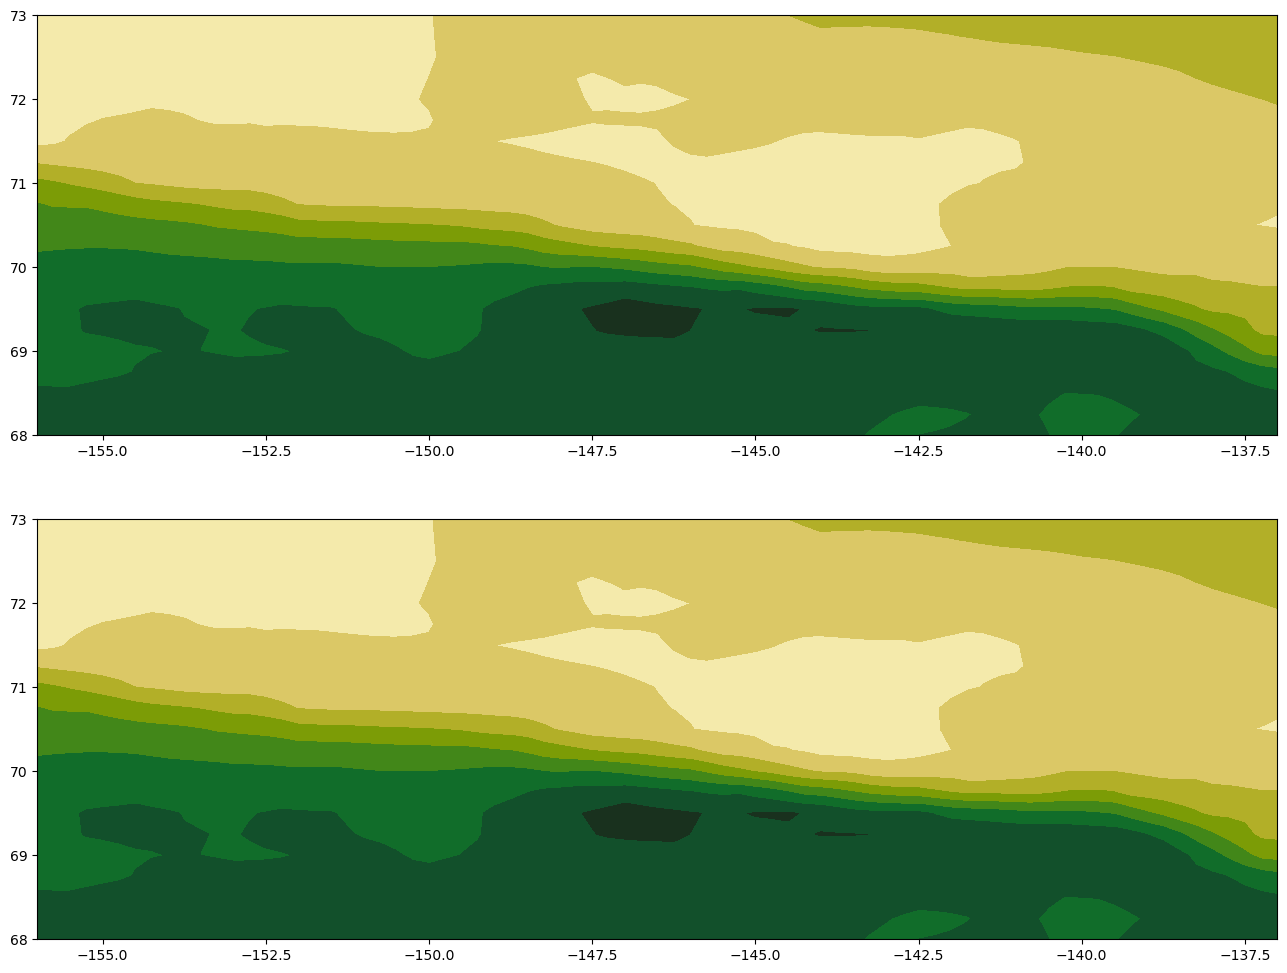

In [19]:
# Make some plots to compare 
# Plot u10 in forcing file and original data 

# Set the time to look at
t1 = 50000

# Make the figure 
fig, ax = plt.subplots(2, figsize=(16,12))

# Plot the forcing data
cs1 = ax[0].contourf(wind_frc_file.lon.values, wind_frc_file.lat.values, wind_frc_file.Uwind[t1,:,:],
            cmap=cmocean.cm.speed)

# Plot the original data
cs2 = ax[1].contourf(era5_winds.longitude.values, era5_winds.latitude.values, era5_winds.u10[t1,:,:].values,
                  cmap=cmocean.cm.speed)



Looks okay to me...